
<style>
:root { --azul:#17364f; --azul2:#2f668f; --cinza:#eef2f4; --ouro:#c77718; }
.jp-RenderedHTMLCommon h1 { color:var(--azul); font-weight:750; border-bottom:4px solid var(--azul); padding-bottom:.28em; }
.jp-RenderedHTMLCommon h2 { color:var(--azul); font-weight:700; }
.jp-RenderedHTMLCommon h3 { color:var(--azul2); }
.tempo { float:right; color:white; background:var(--azul); border-radius:4px; padding:.2em .55em; font-size:.55em; }
.pergunta { font-size:1.25em; color:var(--azul); font-weight:700; margin:.8em 0; }
.destaque { border-left:7px solid var(--ouro); background:#fff7ea; padding:.8em 1em; margin:1em 0; }
.aviso { border-left:7px solid var(--azul2); background:var(--cinza); padding:.8em 1em; margin:1em 0; }
.etapas { border-collapse:collapse; width:100%; }
.etapas th { background:var(--azul); color:white; text-align:left; padding:.65em; }
.etapas td { padding:.65em; vertical-align:top; }
.etapas tr:nth-child(even) { background:var(--cinza); }
details { background:var(--cinza); padding:.65em .9em; margin-top:1em; border-radius:4px; }
summary { color:var(--azul); font-weight:700; cursor:pointer; }
.fonte { color:#536674; font-size:.85em; }
</style>
# Donk é um outlier entre os melhores da FACEIT?

### Uma análise semanal de K/D entre os top 500 da Europa

**Season 9 · 05/08 a 29/09/2026 · dados reais da FACEIT**

<div class="aviso"><strong>Questão central:</strong> o desempenho de donk666 fica fora do padrão mesmo quando a comparação se restringe à elite da plataforma?</div>

<p class="fonte">Grupo fixado em 01/10/2026. Apresentação de aproximadamente 15 minutos.</p>

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display, Image

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from scripts.analyze_weekly import load_verified
from src.weekly import aggregate_weekly, classify_weekly

cohort, matches, missing, coverage, manifest = load_verified()
OUT = ROOT / "outputs" / "season9_weekly"
donk = pd.read_csv(OUT / "donk_weekly.csv")
weekly_stats = pd.read_csv(OUT / "weekly_statistics.csv")
sensitivity = pd.read_csv(OUT / "sensitivity_donk.csv")


## Roteiro da apresentação

<table class="etapas">
<thead><tr><th>Etapa</th><th>Tempo</th><th>O que mostrar</th></tr></thead>
<tbody>
<tr><td>Problema e objetivo</td><td>2 min</td><td>Pergunta, grupo de comparação e dados analisados.</td></tr>
<tr><td>Conceito estatístico</td><td>3 min</td><td>K/D semanal, boxplot, IQR e regra de outliers.</td></tr>
<tr><td>Demonstração do sistema</td><td>6 min</td><td>Entrada, processamento, resultados e o caso do donk.</td></tr>
<tr><td>Conclusão e limites</td><td>2 min</td><td>O que os resultados sustentam e o que permanece limitado.</td></tr>
<tr><td>Perguntas</td><td>2 min</td><td>Respostas sobre seleção, métrica, lacunas e reprodução.</td></tr>
</tbody></table>

# 1. Problema e objetivo <span class="tempo">2 min</span>

<div class="pergunta">Donk apresenta um K/D semanal excepcional mesmo entre os atuais top 500 da região EU?</div>

O projeto busca separar uma impressão visual de uma diferença mensurável em relação a jogadores de nível semelhante.

- **Grupo fixo:** os 500 primeiros do ranking EU na data da coleta.
- **Usuário da análise:** quem avalia desempenho competitivo na FACEIT.
- **Decisão apoiada:** identificar em quais semanas o desempenho ficou fora do padrão da elite.
- **Unidade de comparação:** um K/D por jogador em cada semana.
- **Período:** oito semanas completas, de 5 de agosto a 29 de setembro.
- **Resultado procurado:** semanas nas quais donk ultrapassa o limite superior do boxplot.

<details><summary>Notas de apresentação</summary>
Comece pela pergunta. Comparar donk com todos os jogadores seria pouco informativo. O top 500 cria uma referência mais exigente. Os mesmos 500 jogadores permanecem nas oito semanas.
</details>

In [2]:
resumo_base = pd.DataFrame([{
    "Jogadores no grupo": len(cohort),
    "Partidas distintas": matches.match_id.nunique(),
    "Participações jogador-partida": len(matches),
    "Lacunas registradas": len(missing),
    "Semanas": 8,
}])
display(resumo_base)
display(cohort.loc[cohort.player.str.lower().eq("donk666"),
                   ["position", "player"]]
        .rename(columns={"position":"Posição", "player":"Jogador"}))

,Jogadores no grupo,Partidas distintas,Participações jogador-partida,Lacunas registradas,Semanas
0,500,42845,83340,33,8


,Posição,Jogador
0,1,donk666


# 2. Conceito estatístico <span class="tempo">3 min</span>

### Uma observação por jogador e semana

Para o jogador $i$ na semana $s$:

$$K/D_{i,s}=\frac{\sum \text{kills}_{i,s}}{\sum \text{deaths}_{i,s}}$$

Usamos a razão dos totais. Uma partida com muitas mortes pesa mais do que uma partida curta, em vez de ambas receberem o mesmo peso por uma média simples de razões.

### Como o boxplot identifica um valor incomum

$$IQR=Q_3-Q_1$$

$$\text{Limite superior}=Q_3+1{,}5\times IQR$$

Um K/D estritamente acima desse limite recebe a classificação **outlier superior**. Calculamos quartis e limites novamente em cada semana.

**Hipótese operacional:** em pelo menos uma semana elegível, o K/D de donk supera $Q_3+1{,}5\times IQR$.

<details><summary>Notas de apresentação</summary>
A caixa contém metade dos jogadores válidos, entre Q1 e Q3. O traço mostra a mediana. Os círculos representam valores além de 1,5 vezes o IQR. Essa regra descreve a distribuição e não constitui um teste de significância.
</details>

In [3]:
exemplo = weekly_stats.loc[weekly_stats.week.eq(1),
    ["q1", "median", "q3", "iqr", "lower_bound", "upper_bound"]].copy()
exemplo.columns = ["Q1", "Mediana", "Q3", "IQR", "Limite inferior", "Limite superior"]
display(exemplo.round(3).rename(index={exemplo.index[0]: "Semana 1"}))

,Q1,Mediana,Q3,IQR,Limite inferior,Limite superior
Semana 1,1.066,1.166,1.291,0.225,0.728,1.629


# 3. Demonstração do sistema <span class="tempo">6 min</span>

## Entrada e cobertura

O sistema parte de três conjuntos verificáveis:

1. fotografia do ranking EU com 500 IDs, posições e Elo;
2. histórico de partidas desses jogadores;
3. estatísticas de kills e deaths de cada participação.

<div class="destaque"><strong>Regra de integridade:</strong> se uma partida esperada não contém estatísticas individuais válidas, o jogador fica fora da caixa daquela semana. A lacuna não vira K/D zero.</div>

<details><summary>Notas de apresentação</summary>
“Participação” significa um jogador do grupo em uma partida. Uma partida pode conter vários integrantes do top 500, por isso o total de participações supera o número de partidas distintas.
</details>

In [4]:
cobertura = pd.DataFrame({
    "Indicador": ["Jogadores consultados", "Partidas distintas", "Participações com estatísticas",
                  "Participações sem estatística recuperável", "Conferências diretas por partida"],
    "Valor": [len(cohort), matches.match_id.nunique(), len(matches), len(missing), 56],
})
display(cobertura)

,Indicador,Valor
0,Jogadores consultados,500
1,Partidas distintas,42845
2,Participações com estatísticas,83340
3,Participações sem estatística recuperável,33
4,Conferências diretas por partida,56


## Processamento

O fluxo aplica as mesmas regras a todos os jogadores:

1. filtra partidas concluídas de matchmaking CS2 5v5;
2. atribui cada partida à semana pelo horário de término em UTC;
3. soma kills e deaths por jogador e semana;
4. elimina jogador-semana com lacuna conhecida;
5. calcula K/D, quartis, limites e classificação.

Quem não jogou em uma semana não recebe zero e não entra naquela caixa.

<details><summary>Notas de apresentação</summary>
Execute a próxima célula ao vivo. Ela recalcula 4.000 combinações possíveis, formadas por 500 jogadores em oito semanas, usando os arquivos verificados.
</details>

In [5]:
weekly_demo, audit_demo = aggregate_weekly(
    cohort, matches, manifest["start_utc"], manifest["end_utc"], missing, min_matches=1
)
weekly_demo, stats_demo = classify_weekly(weekly_demo)
display(pd.DataFrame([{
    "Combinações jogador-semana": len(weekly_demo),
    "Com K/D elegível": int(weekly_demo.kd.notna().sum()),
    "Sem partidas": int(weekly_demo.status.eq("sem_partidas").sum()),
    "Com dados incompletos": int(weekly_demo.status.eq("dados_incompletos").sum()),
}]))

,Combinações jogador-semana,Com K/D elegível,Sem partidas,Com dados incompletos
0,4000,3691,276,33


## Tela de resultados

Cada caixa mostra a distribuição do K/D semanal. O losango laranja representa donk666. O número acima dele informa quantas partidas sustentam seu K/D.

<details><summary>Como apresentar o gráfico</summary>
Leia da esquerda para a direita. A mediana do grupo permanece próxima de 1,18 a 1,20. Depois compare o losango com o limite superior. Na semana 4, uma partida esperada não possui a estatística individual do donk.
</details>

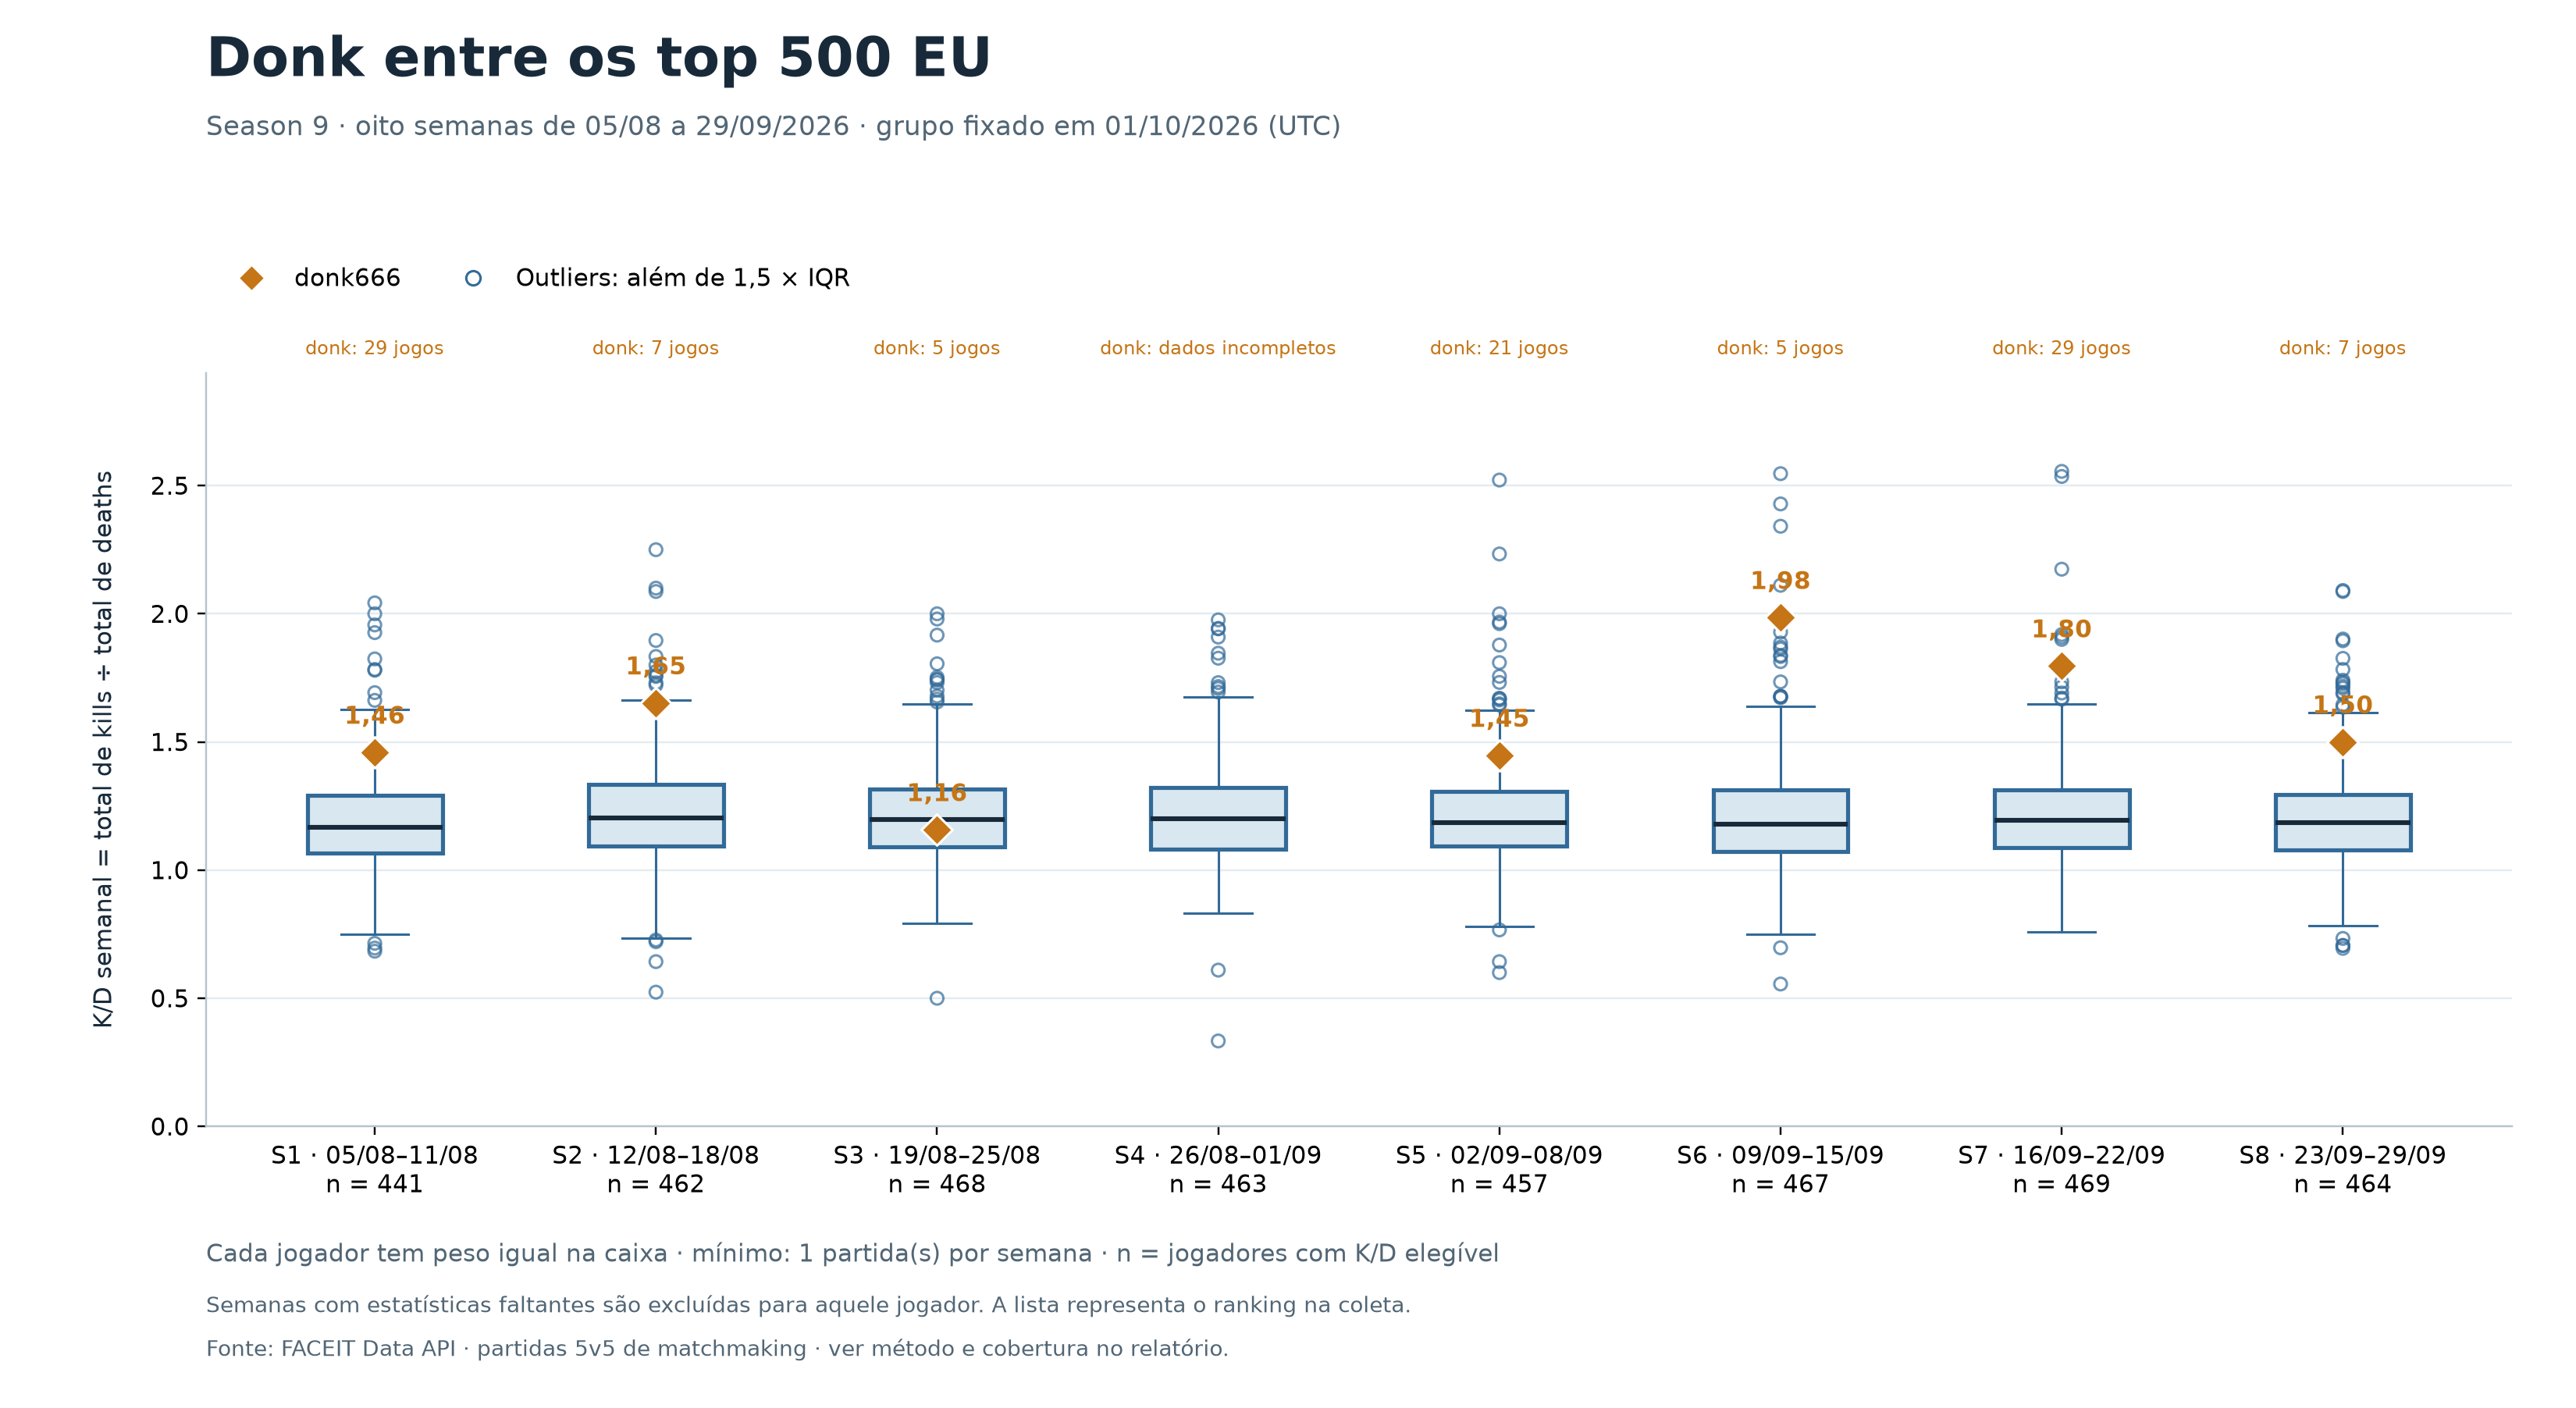

In [6]:
display(Image(filename=str(OUT / 'boxplot_semanal.png')))

## Caso de uso: donk666

- **Semanas 6 e 7:** outlier superior.
- **Semana 4:** dados incompletos, sem classificação.
- **Demais semanas elegíveis:** desempenho dentro dos limites do boxplot.

<div class="destaque"><strong>Leitura central:</strong> donk foi excepcional em duas das sete semanas avaliáveis. A evidência mais sólida vem da semana 7, baseada em 29 partidas.</div>

<details><summary>Notas de apresentação</summary>
Na semana 6, o K/D de 1,98 supera o limite de 1,67, mas deriva de cinco partidas. Na semana 7, o K/D de 1,80 supera o limite de 1,65 com 29 partidas e permanece outlier quando exigimos pelo menos dez partidas por jogador.
</details>

In [7]:
resultado_donk = donk[["week", "matches", "missing_matches", "kd", "median",
                               "upper_bound", "percentile", "classification"]].copy()
resultado_donk.columns = ["Semana", "Partidas", "Lacunas", "K/D donk", "Mediana",
                          "Limite superior", "Percentil", "Classificação"]
resultado_donk["Classificação"] = resultado_donk["Classificação"].replace({
    "normal": "Dentro dos limites",
    "outlier_positivo": "Outlier superior",
    "dados_incompletos": "Dados incompletos",
})
display(resultado_donk.round(3).set_index("Semana"))

,Partidas,Lacunas,K/D donk,Mediana,Limite superior,Percentil,Classificação
Semana,,,,,,,
1,29,0,1.459,1.166,1.629,92.290,Dentro dos limites
2,7,0,1.652,1.202,1.694,97.186,Dentro dos limites
3,5,0,1.157,1.196,1.651,40.812,Dentro dos limites
4,16,1,NaN,1.199,1.682,NaN,Dados incompletos
5,21,0,1.447,1.186,1.627,89.934,Dentro dos limites
6,5,0,1.985,1.180,1.669,98.929,Outlier superior
7,29,0,1.796,1.195,1.654,98.507,Outlier superior
8,7,0,1.500,1.185,1.620,93.750,Dentro dos limites


## Sensibilidade ao volume de partidas

O mínimo principal aceita uma partida. Também repetimos a análise exigindo cinco e dez partidas por jogador-semana.

- Com mínimo de **cinco partidas**, donk continua outlier nas semanas 6 e 7.
- Com mínimo de **dez partidas**, a semana 6 deixa de ser elegível.
- A semana 7 permanece outlier superior com 29 jogos.

<details><summary>Notas de apresentação</summary>
A análise de sensibilidade evita tratar um K/D alto em poucos jogos como evidência igualmente forte. A classificação da semana 7 é a conclusão mais estável.
</details>

In [8]:
sens_donk = sensitivity.loc[sensitivity.minimum_matches.isin([1, 5, 10]),
    ["week", "minimum_matches", "matches", "kd", "analyzed_players", "upper_bound", "classification"]].copy()
sens_donk.columns = ["Semana", "Mínimo exigido", "Partidas do donk", "K/D donk",
                     "Jogadores válidos", "Limite superior", "Classificação"]
display(sens_donk.round(3).set_index(["Semana", "Mínimo exigido"]))

,,Partidas do donk,K/D donk,Jogadores válidos,Limite superior,Classificação
Semana,Mínimo exigido,,,,,
1,1,29,1.459,441,1.629,normal
2,1,7,1.652,462,1.694,normal
3,1,5,1.157,468,1.651,normal
4,1,16,NaN,463,1.682,dados_incompletos
5,1,21,1.447,457,1.627,normal
6,1,5,1.985,467,1.669,outlier_positivo
7,1,29,1.796,469,1.654,outlier_positivo
8,1,7,1.500,464,1.620,normal
1,5,29,1.459,410,1.618,normal


# 4. Conclusão e limites <span class="tempo">2 min</span>

## O que o resultado sustenta

Donk ultrapassou o limite superior nas semanas 6 e 7. A semana 7 fornece a evidência mais consistente: 29 partidas, K/D de 1,80 e percentil aproximado de 98,5.

## Limites que acompanham a conclusão

- O grupo representa o top 500 em 01/10/2026, não o ranking de cada semana.
- K/D não captura todo o impacto de um jogador.
- A quantidade de partidas varia entre jogadores e semanas.
- A regra de 1,5 × IQR descreve valores incomuns, sem testar significância.
- A primeira semana começa à meia-noite UTC por convenção do estudo.

<details><summary>Notas de apresentação</summary>
Retome a pergunta inicial. A resposta é “sim, em semanas específicas”. Destaque a semana 7 como o caso mais convincente.
</details>

# 5. Perguntas <span class="tempo">2 min</span>

### Por que usar os top 500 atuais?
A API disponibiliza o ranking atual de forma verificável. Salvamos uma fotografia fixa para que o grupo não mude.

### Por que K/D em vez do FACEIT Rating?
O Rating do site não apareceu na API consultada. Kills e deaths permitem reproduzir o cálculo.

### Por que o donk não aparece na semana 4?
Uma partida esperada não contém sua estatística individual. Excluímos a semana para evitar K/D parcial.

### Quinhentos jogadores são necessários?
O tamanho oferece uma referência ampla da elite e estabiliza os quartis.

### Como reproduzir o resultado?
O notebook lê arquivos verificados por manifesto, recalcula as semanas e mantém as respostas originais em cache local.

<div class="aviso"><strong>Arquivos de apoio:</strong> relatório, CSVs e manifestos estão em <code>outputs/season9_weekly</code> e <code>data/season9_top500</code>.</div>